# Data exploration

Explore the existing SPY raw dataset with basic data summaries, quality checks, and charts. This is descriptive analysis only: it does not test hypotheses or provide predictive evidence.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Could not find the project root (pyproject.toml) from the current directory.")

project_root = find_project_root(Path.cwd())
sys.path.insert(0, str(project_root / "src"))

from card53.config.settings import load_settings
from card53.data.loaders import load_market_data
from card53.data.validation import validate_market_data
from card53.features.returns import simple_returns
from card53.features.volatility import rolling_volatility

In [2]:
# Load the existing configured raw-data file; no network request is made.
settings = load_settings(project_root / "config" / "research.yaml")
spy_path = project_root / settings.raw_data_dir / "SPY.csv"
if not spy_path.is_file():
    raise FileNotFoundError(f"Existing SPY raw dataset was not found: {spy_path}")

spy = load_market_data(spy_path)
spy = validate_market_data(
    spy,
    required_columns=("Open", "High", "Low", "Close", "Adj Close", "Volume"),
)
daily_returns = simple_returns(spy["Close"])

print(f"Dataset: {spy_path.relative_to(project_root)}")
print(f"Shape: {spy.shape}")
print(f"Date range: {spy.index.min().date()} to {spy.index.max().date()}")
print(f"Columns: {spy.columns.tolist()}")
print("\nFirst 5 rows")
display(spy.head())
print("\nLast 5 rows")
display(spy.tail())
print("\nData types")
display(spy.dtypes.rename("dtype").to_frame())

print("\nDescriptive statistics: OHLC and Volume")
display(spy[["Open", "High", "Low", "Close", "Volume"]].describe().T)
print("\nDescriptive statistics: daily Close-to-close returns")
display(daily_returns.describe().to_frame(name="daily return").T)

Dataset: data\raw\SPY.csv
Shape: (4213, 6)
Date range: 2010-01-04 to 2026-10-02
Columns: ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

First 5 rows


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-01-04,112.370003,113.389999,111.510002,113.330002,84.368965,118944600
2010-01-05,113.260002,113.680000,112.849998,113.629997,84.592331,111579900
2010-01-06,113.519997,113.989998,113.430000,113.709999,84.651863,116074400
2010-01-07,113.500000,114.330002,113.180000,114.190002,85.009201,131091100
2010-01-08,113.889999,114.620003,113.660004,114.570000,85.292076,126402800



Last 5 rows


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2026-09-28,768.349976,769.539978,763.719971,765.609985,765.609985,42694500
2026-09-29,766.830017,766.979980,762.349976,764.200012,764.200012,36910500
2026-09-30,766.450012,769.409973,762.179993,762.630005,762.630005,62110000
2026-10-01,764.359985,765.650024,758.789978,763.989990,763.989990,47708100
2026-10-02,770.580017,772.650024,767.150024,769.640015,769.640015,46306400



Data types


,dtype
Open,float64
High,float64
Low,float64
Close,float64
Adj Close,float64
Volume,int64



Descriptive statistics: OHLC and Volume


,count,mean,std,min,25%,50%,75%,max
Open,4213.0,3.132537e+02,1.702832e+02,1.031100e+02,1.849600e+02,2.677400e+02,4.225200e+02,7.785400e+02
High,4213.0,3.149047e+02,1.710842e+02,1.034200e+02,1.861400e+02,2.697000e+02,4.248700e+02,7.793700e+02
Low,4213.0,3.114499e+02,1.693805e+02,1.011300e+02,1.839100e+02,2.661100e+02,4.193200e+02,7.754300e+02
Close,4213.0,3.133081e+02,1.702990e+02,1.022000e+02,1.849800e+02,2.675800e+02,4.221100e+02,7.778800e+02
Volume,4213.0,1.072653e+08,6.733217e+07,2.027000e+07,6.385500e+07,8.747720e+07,1.300110e+08,7.178287e+08



Descriptive statistics: daily Close-to-close returns


,count,mean,std,min,25%,50%,75%,max
daily return,4212.0,0.000513,0.010773,-0.109424,-0.003809,0.000646,0.005775,0.105019


In [3]:
# Flag suspicious calendar gaps for review; market holidays can create multi-day gaps.
invalid_ohlc = (
    (spy["High"] < spy[["Open", "Close", "Low"]].max(axis=1))
    | (spy["Low"] > spy[["Open", "Close", "High"]].min(axis=1))
)
calendar_gaps = spy.index.to_series().diff().dt.days
suspicious_gaps = calendar_gaps[calendar_gaps > 4]

quality_summary = pd.Series(
    {
        "Duplicate dates": int(spy.index.duplicated().sum()),
        "Rows with missing values": int(spy.isna().any(axis=1).sum()),
        "Missing values by column (total)": int(spy.isna().sum().sum()),
        "Chronologically ordered": bool(spy.index.is_monotonic_increasing),
        "Invalid OHLC rows": int(invalid_ohlc.sum()),
        "Non-positive volume rows": int((spy["Volume"] <= 0).sum()),
        "Calendar gaps over 4 days": int(len(suspicious_gaps)),
    },
    name="Result",
)
print("Data quality checks")
display(quality_summary.to_frame())
print("Missing values by column")
display(spy.isna().sum().rename("missing values").to_frame())

if suspicious_gaps.empty:
    print("No calendar gaps longer than four days found.")
else:
    gap_details = pd.DataFrame(
        {
            "previous_date": spy.index.to_series().shift(1).loc[suspicious_gaps.index],
            "date": suspicious_gaps.index,
            "calendar_days": suspicious_gaps,
        }
    )
    display(gap_details)

Data quality checks


,Result
Duplicate dates,0
Rows with missing values,0
Missing values by column (total),0
Chronologically ordered,True
Invalid OHLC rows,0
Non-positive volume rows,0
Calendar gaps over 4 days,1


Missing values by column


,missing values
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


,previous_date,date,calendar_days
Date,,,
2012-10-31,2012-10-26,2012-10-31,5.0


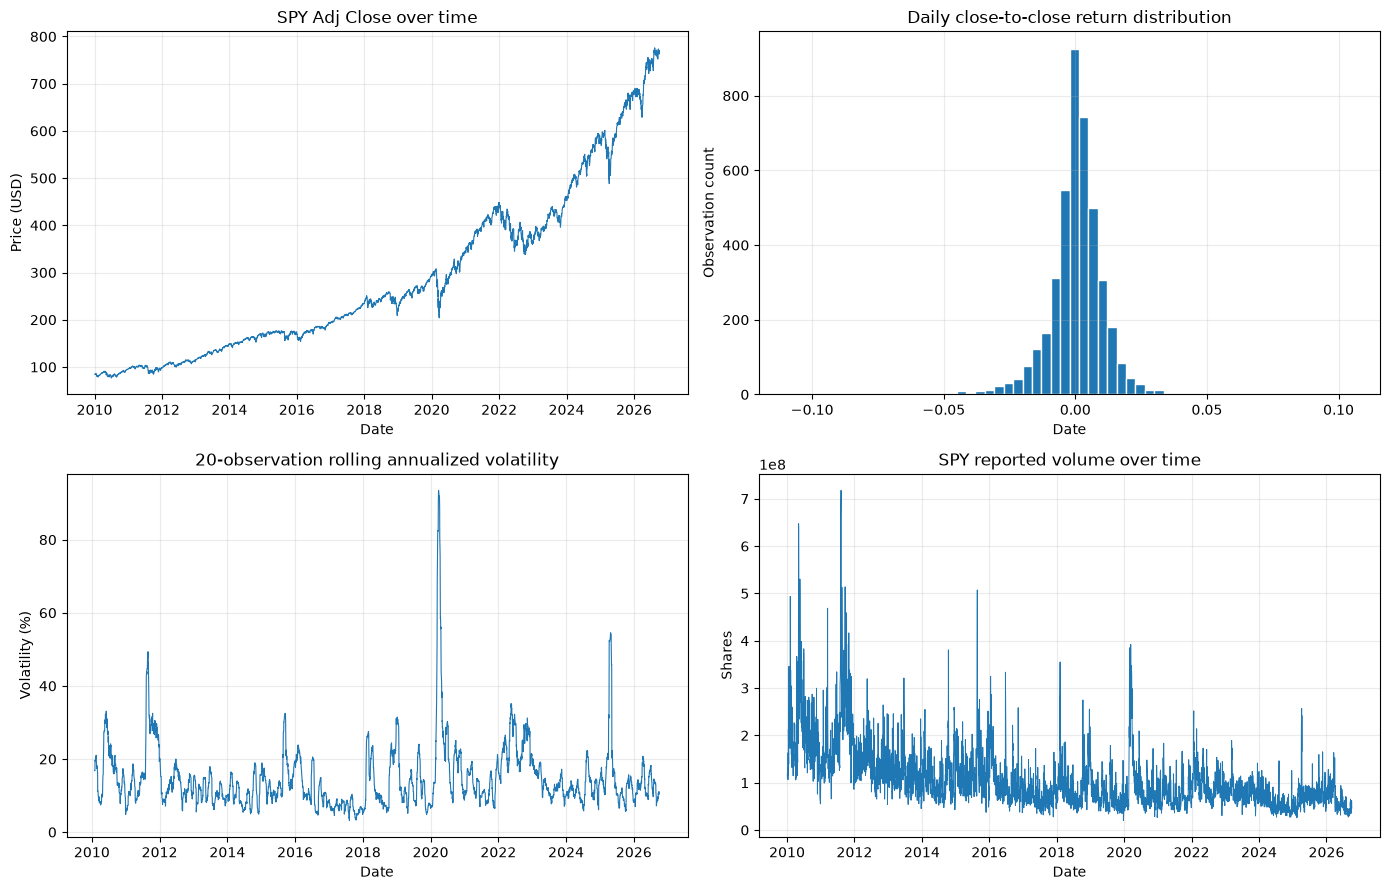

In [4]:
# Plot adjusted close when available; rolling volatility uses the project's feature function.
price_column = "Adj Close" if "Adj Close" in spy.columns else "Close"
annualized_volatility = rolling_volatility(spy["Close"])

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0, 0].plot(spy.index, spy[price_column], linewidth=0.8)
axes[0, 0].set_title(f"SPY {price_column} over time")
axes[0, 0].set_ylabel("Price (USD)")

axes[0, 1].hist(daily_returns, bins=60, edgecolor="white")
axes[0, 1].set_title("Daily close-to-close return distribution")
axes[0, 1].set_xlabel("Simple return")
axes[0, 1].set_ylabel("Observation count")

axes[1, 0].plot(annualized_volatility.index, annualized_volatility * 100, linewidth=0.8)
axes[1, 0].set_title("20-observation rolling annualized volatility")
axes[1, 0].set_ylabel("Volatility (%)")

axes[1, 1].plot(spy.index, spy["Volume"], linewidth=0.7)
axes[1, 1].set_title("SPY reported volume over time")
axes[1, 1].set_ylabel("Shares")

for axis in axes.flat:
    axis.grid(alpha=0.25)
    axis.set_xlabel("Date")

fig.tight_layout()
plt.show()